[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api
[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['FM original'] and nodes: [1, 2, 3, 4, 5, 6, 7, 9, 10]

🚀 Starting Campaign: FM original
  ↳ Node 1 loaded instantly from local cache
  ↳ Node 2 loaded instantly from local cache
  ↳ Node 3 loaded instantly from local cache
  ↳ Node 4 loaded instantly from local cache
  ↳ Node 5 loaded instantly from local cache
  ↳ Node 6 loaded instantly from local cache
  ↳ Node 7 loaded instantly from local cache
  ↳ Node 9 loaded instantly from local cache
  ↳ Node 10 loaded instantly from local cache
[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.


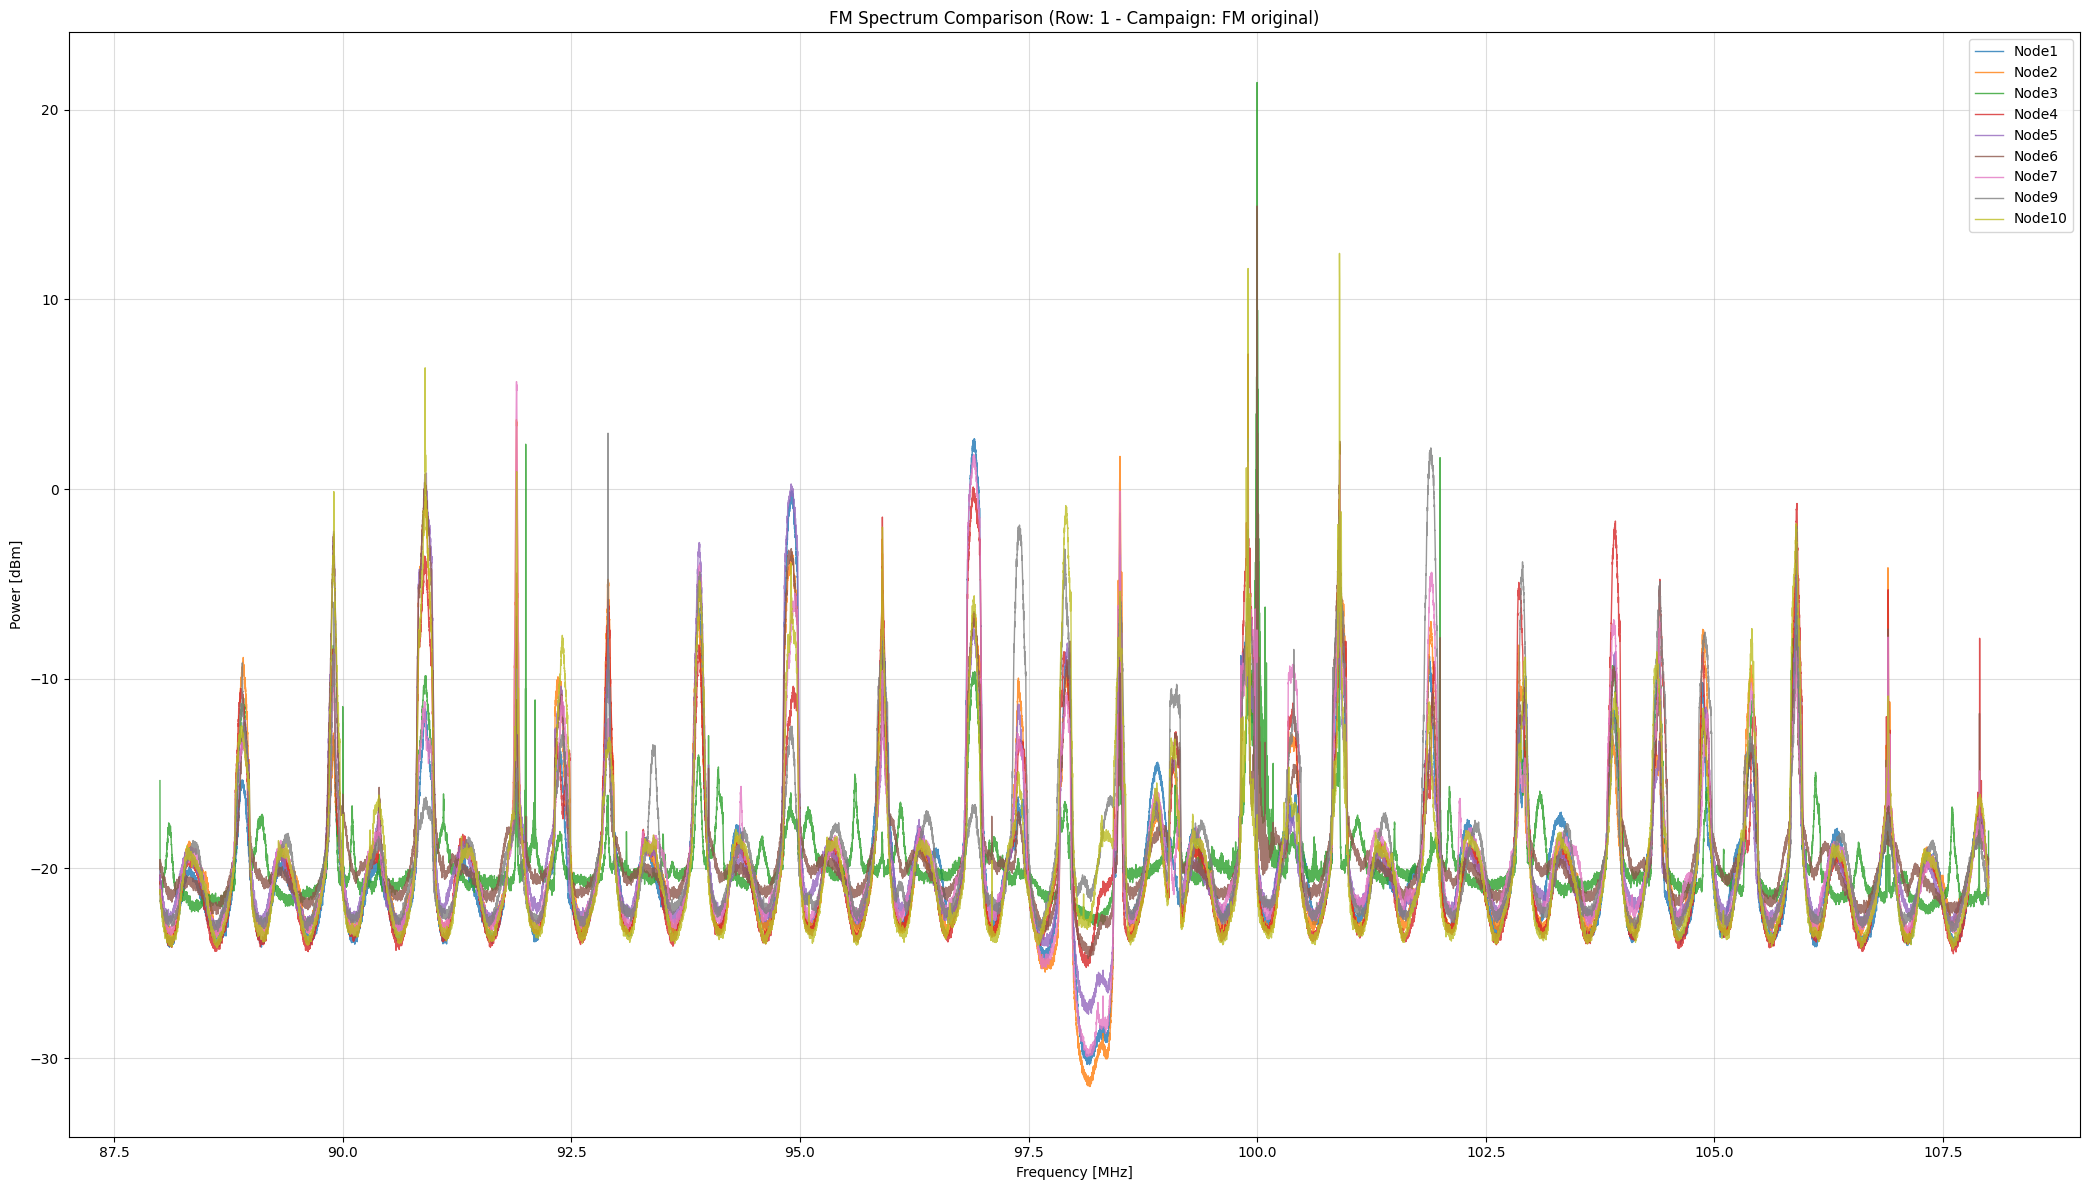

In [ ]:
import sys
sys.path.append('..')

import cfg
import matplotlib.pyplot as plt
import numpy as np
from libs.data_request import DataRequest

log = cfg.set_logger()

camp_ids = {'FM original': 176}
target_nodes = [1, 2, 3, 4, 5, 6, 7, 9, 10]

dr = DataRequest(log=log, base_url=cfg.API_URL)

# Load all data
df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)

# Plotting configuration
campaign_label = "FM original"
data_nodes = df_full[campaign_label]
ROW_PLOT = 1  

plt.figure(figsize=(21, 12))

for node_name, df in data_nodes.items():
    if ROW_PLOT < len(df):
        row = df.iloc[ROW_PLOT]
        pxx = np.array(row['pxx'])
        
        f_start = row['start_freq_hz'] / 1e6
        f_end = row['end_freq_hz'] / 1e6
        frequencies = np.linspace(f_start, f_end, len(pxx))
        
        plt.plot(frequencies, pxx, label=node_name, linewidth=1, alpha=0.8)

plt.title(f"FM Spectrum Comparison (Row: {ROW_PLOT} - Campaign: {campaign_label})")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.legend(loc='best')
plt.grid(True, alpha=0.42)
plt.tight_layout()
plt.show()